# Procesamiento de audio con transformadas de fourier

Esta notebook muestra cómo aplicar un filtro pasa bajas a una señal de audio usando transformadas discretas de Fourier (DFT) en Python.

Puedes usarla para cargar un WAV, examinar su comportamiento en el dominio del tiempo y la frecuencia, filtrar las componentes no deseadas y guardar/reproducir el resultado desde el notebook.

Aquí verás paso a paso qué hace el proceso de filtrado:

- Leer un archivo WAV desde disco con `scipy.io.wavfile.read`.
- Convertir la señal a punto flotante normalizado para trabajar con la DFT.
- Calcular la transformada discreta de Fourier (DFT) usando `fft(data)`.
- Determinar el eje de frecuencias con `fftfreq(N, 1 / fs)`.
- Aplicar un filtro pasa bajas en el dominio de la frecuencia.
- Reconstruir la señal en el dominio del tiempo con `ifft(X_filtered)`.
- Guardar el resultado filtrado en un archivo WAV.
- Reproducir audio original y filtrado desde el notebook.

## ¿Qué hace exactamente la DFT?

La DFT convierte una señal de audio del dominio del tiempo al dominio de la frecuencia. Esto significa que en lugar de ver cómo cambia la amplitud con el tiempo, se ve cuánta energía hay en cada componente de frecuencia.

- `data`: es la señal original en el dominio del tiempo.
- `fs`: es la frecuencia de muestreo en hercios (Hz).
- `N`: es el número de muestras de la señal.
- `X = fft(data)`: es el espectro complejo de la señal.
- `freqs = fftfreq(N, 1 / fs)`: son las frecuencias asociadas a cada bin del espectro.
- `np.abs(X)`: es la magnitud de cada componente de frecuencia.
- `np.angle(X)`: es la fase de cada componente de frecuencia.
- `filter_mask = np.abs(freqs) <= cutoff_freq`: selecciona solo las componentes de frecuencia bajas.
- `X_filtered = X * filter_mask`: atenúa o elimina las frecuencias altas.
- `data_filtered = ifft(X_filtered)`: vuelve a transformar el espectro filtrado al dominio del tiempo.

### Por qué la DFT es útil aquí

- La DFT descompone la señal en un conjunto de senos y cosenos de diferentes frecuencias.
- Cada bin del espectro representa la contribución de una frecuencia específica a la señal original.
- Filtrar en el dominio de la frecuencia permite eliminar directamente las componentes no deseadas.
- La reconstrucción inversa con `ifft` devuelve una señal de audio adecuada para escucha.

## Detalles importantes de la DFT

- La DFT asume que la señal es periódica y se procesa en bloques finitos de tamaño `N`.
- `fftfreq(N, 1 / fs)` devuelve frecuencias positivas y negativas, porque la DFT es simétrica para señales reales.
- El filtro se aplica a ambas mitades del espectro para mantener la simetría y evitar distorsión al volver al dominio del tiempo.
- Al usar `np.real(ifft(...))`, se descarta una posible pequeña componente imaginaria que se genera por errores numéricos.

## Qué representa cada paso

1. `data = data.astype(np.float32)` y normalizar: lleva la señal al rango [-1, 1].
2. `fft(data)`: obtiene la representación en frecuencia.
3. `fftfreq(N, 1 / fs)`: calcula las frecuencias asociadas a cada elemento del espectro.
4. `filter_mask`: define qué frecuencias pasar y cuáles bloquear.
5. `X_filtered = X * filter_mask`: aplica el filtro multiplicando el espectro.
6. `ifft(X_filtered)`: transforma el espectro filtrado al dominio del tiempo.
7. `np.real(...)`: toma la parte real del resultado complejo.
8. Normalizar de nuevo y convertir a `int16` para guardar WAV.

## Qué verás en el notebook

- La señal original en el dominio del tiempo.
- La señal filtrada en el dominio del tiempo.
- La explicación de cómo se construye y aplica el filtro en frecuencia.
- La relación entre frecuencia de corte y contenido de audio.

## Cómo utilizar esta notebook

1. Coloca tu archivo WAV en la carpeta `uploads/`.
2. Cambia `input_path = 'uploads/tu_audio.wav'` por el nombre de tu archivo.
3. Ejecuta las celdas de código.
4. El audio filtrado se guarda en `processed/filtered_notebook.wav`.

Este notebook está pensado para aprender y experimentar con Fourier y filtrado de audio.


In [71]:
import numpy as np
import scipy.io.wavfile as wavfile
from scipy.fft import fft, ifft, fftfreq
from pathlib import Path
from IPython.display import Audio, display
import matplotlib.pyplot as plt

def lowpass_filter(data, fs, cutoff_freq=4000):
    if data.ndim > 1:
        data = data[:, 0]  # usar canal izquierdo si es estéreo

    # Normalizar a [-1, 1] igual que la web (app.py)
    data = data.astype(np.float32)
    if np.max(np.abs(data)) > 1.0:  # es int16 sin normalizar
        data = data / 32768.0

    N = len(data)
    X = fft(data)
    freqs = fftfreq(N, 1 / fs)

    filter_mask = np.abs(freqs) <= cutoff_freq
    X_filtered = X * filter_mask

    # Energía calculada ANTES de normalizar el volumen, igual que app.py
    data_filtered_raw = np.real(ifft(X_filtered))

    # Normalizar volumen para el archivo de salida
    max_val = np.max(np.abs(data_filtered_raw))
    if max_val > 0:
        data_filtered_out = data_filtered_raw / max_val * 0.99
    else:
        data_filtered_out = data_filtered_raw

    data_output = (data_filtered_out * 32767).astype(np.int16)
    # Retornar data_filtered_raw para que process_wav_file calcule energía correctamente
    return data_output, data_filtered_raw, X, X_filtered, freqs

def plot_processing(data, data_filtered, X, X_filtered, freqs, fs, cutoff_freq):
    N = len(data)
    t = np.arange(N) / fs
    half_N = N // 2
    positive_freqs = freqs[:half_N]
    positive_X = np.abs(X[:half_N])
    positive_X_filtered = np.abs(X_filtered[:half_N])

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(
        'Visualizacion del Procesamiento de Audio con Filtro Pasa Bajas (FFT)',
        fontsize=14, fontweight='bold'
    )

    axs[0, 0].plot(t, data, color='#1f77b4', alpha=0.7)
    axs[0, 0].set_title('Audio Original (Tiempo)', fontsize=10, fontweight='bold')
    axs[0, 0].set_xlabel('Tiempo (s)', fontsize=8)
    axs[0, 0].set_ylabel('Amplitud', fontsize=8)
    axs[0, 0].grid(True, linestyle='--', alpha=0.6)

    axs[0, 1].plot(positive_freqs, positive_X, color='#ff7f0e', alpha=0.7)
    axs[0, 1].set_title('Espectro FFT Original (Frecuencia)', fontsize=10, fontweight='bold')
    axs[0, 1].set_xlabel('Frecuencia (Hz)', fontsize=8)
    axs[0, 1].set_ylabel('Magnitud (Escala Log)', fontsize=8)
    axs[0, 1].set_yscale('log')
    axs[0, 1].grid(True, linestyle='--', alpha=0.6)

    axs[1, 0].plot(t, data_filtered, color='#2ca02c', alpha=0.7)
    axs[1, 0].set_title('Audio Filtrado (Tiempo)', fontsize=10, fontweight='bold')
    axs[1, 0].set_xlabel('Tiempo (s)', fontsize=8)
    axs[1, 0].set_ylabel('Amplitud', fontsize=8)
    axs[1, 0].grid(True, linestyle='--', alpha=0.6)

    axs[1, 1].plot(positive_freqs, positive_X_filtered, color='#d62728', alpha=0.7)
    axs[1, 1].set_title('Espectro FFT Filtrado (Frecuencia)', fontsize=10, fontweight='bold')
    axs[1, 1].set_xlabel('Frecuencia (Hz)', fontsize=8)
    axs[1, 1].set_ylabel('Magnitud (Escala Log)', fontsize=8)
    axs[1, 1].set_yscale('log')
    axs[1, 1].axvline(x=cutoff_freq, color='black', linestyle='--', alpha=0.8,
                      label=f'Corte: {int(cutoff_freq)} Hz')
    axs[1, 1].legend(fontsize=8)
    axs[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def process_wav_file(input_path, output_path=None, cutoff_freq=4000):
    input_path = Path(input_path)
    if output_path is None:
        output_path = Path('processed') / f'notebook_filtered_{input_path.stem}.wav'
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fs, data = wavfile.read(str(input_path))
    # Preparar señal original normalizada para energía y gráfica (igual que app.py)
    data_float = data[:, 0] if data.ndim > 1 else data
    data_float = data_float.astype(np.float32)
    if np.max(np.abs(data_float)) > 1.0:
        data_float = data_float / 32768.0

    data_output, data_filtered, X, X_filtered, freqs = lowpass_filter(data, fs, cutoff_freq)
    wavfile.write(str(output_path), fs, data_output)

    # Energía calculada igual que app.py:
    # - original: sobre data normalizado a [-1,1]
    # - filtrada: sobre ifft result ANTES de normalizar volumen
    original_energy = float(np.sum(data_float ** 2))
    filtered_energy = float(np.sum(data_filtered ** 2))

    data_plot = data_float

    return {
        'input': str(input_path),
        'output': str(output_path),
        'fs': int(fs),
        'duration_s': round(len(data_output) / fs, 2),
        'original_energy': original_energy,
        'filtered_energy': filtered_energy,
        'cutoff_freq': cutoff_freq,
        # datos para graficar (no serializar, solo en memoria)
        '_data_plot': data_plot,
        '_data_filtered': data_filtered,
        '_X': X,
        '_X_filtered': X_filtered,
        '_freqs': freqs,
    }


🎚️ Frec. de muestreo,48000 Hz
⏱️ Duración,7.1 s
✂️ Frec. de corte,20000 Hz
⚡ Energía original,3360.69
⚡ Energía filtrada,3360.69
📉 Reducción de energía,-0.0%

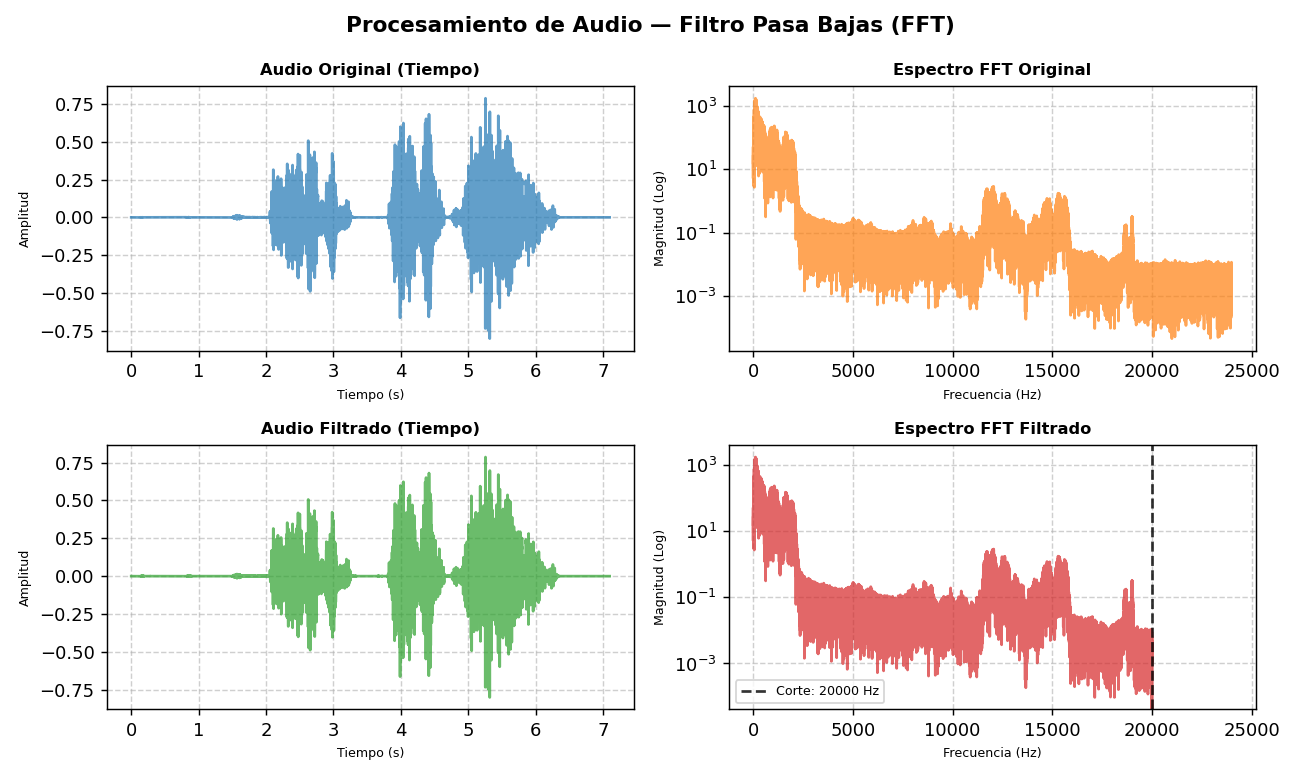

In [ ]:
input_path = 'processed/856648__skylosaurus__robot-bear-growl_1.wav'
output_path = 'uploads/tu_audio.wav'

result = process_wav_file(input_path, output_path, 9700)

from IPython.display import HTML, display as ipy_display, Audio
import io, base64, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

reduction = (1 - result['filtered_energy'] / result['original_energy']) * 100
reduction_color = '#e74c3c' if reduction > 0 else '#2ecc71'

# --- Leer template externo ---
with open('resultado_template.txt', 'r', encoding='utf-8') as _f:
    _tpl = _f.read()

html_metrics = _tpl.format(
    input=result['input'],
    output=result['output'],
    fs=result['fs'],
    duration_s=result['duration_s'],
    cutoff_freq=int(result['cutoff_freq']),
    original_energy=f"{result['original_energy']:.2f}",
    filtered_energy=f"{result['filtered_energy']:.2f}",
    reduction=f"{reduction:.1f}",
    reduction_color=reduction_color,
)

# --- Gráfica usando los datos exactos del filtro (no re-leer el WAV) ---
_data    = result['_data_plot']
_dfilt   = result['_data_filtered']
X        = result['_X']
Xf       = result['_X_filtered']
freqs    = result['_freqs']
fs_val   = result['fs']
cutoff   = result['cutoff_freq']

N      = len(_data)
half   = N // 2
t      = np.arange(N) / fs_val
pfreqs = freqs[:half]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Procesamiento de Audio — Filtro Pasa Bajas (FFT)', fontsize=12, fontweight='bold')

axs[0,0].plot(t, _data, color='#1f77b4', alpha=0.7)
axs[0,0].set_title('Audio Original (Tiempo)', fontsize=9, fontweight='bold')
axs[0,0].set_xlabel('Tiempo (s)', fontsize=7); axs[0,0].set_ylabel('Amplitud', fontsize=7)
axs[0,0].grid(True, linestyle='--', alpha=0.6)

axs[0,1].plot(pfreqs, np.abs(X[:half]), color='#ff7f0e', alpha=0.7)
axs[0,1].set_title('Espectro FFT Original', fontsize=9, fontweight='bold')
axs[0,1].set_xlabel('Frecuencia (Hz)', fontsize=7); axs[0,1].set_ylabel('Magnitud (Log)', fontsize=7)
axs[0,1].set_yscale('log'); axs[0,1].grid(True, linestyle='--', alpha=0.6)

axs[1,0].plot(t, _dfilt, color='#2ca02c', alpha=0.7)
axs[1,0].set_title('Audio Filtrado (Tiempo)', fontsize=9, fontweight='bold')
axs[1,0].set_xlabel('Tiempo (s)', fontsize=7); axs[1,0].set_ylabel('Amplitud', fontsize=7)
axs[1,0].grid(True, linestyle='--', alpha=0.6)

axs[1,1].plot(pfreqs, np.abs(Xf[:half]), color='#d62728', alpha=0.7)
axs[1,1].set_title('Espectro FFT Filtrado', fontsize=9, fontweight='bold')
axs[1,1].set_xlabel('Frecuencia (Hz)', fontsize=7); axs[1,1].set_ylabel('Magnitud (Log)', fontsize=7)
axs[1,1].set_yscale('log')
axs[1,1].axvline(x=cutoff, color='black', linestyle='--', alpha=0.8, label=f'Corte: {int(cutoff)} Hz')
axs[1,1].legend(fontsize=7); axs[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=130)
plt.close()
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode()

# --- Layout lado a lado ---
combined = f"""
<div style="display:flex; gap:20px; align-items:flex-start; flex-wrap:wrap;">
  <div style="flex:0 0 auto;">
    <img src="data:image/png;base64,{img_b64}" style="max-width:755px; border-radius:10px; box-shadow:0 4px 16px rgba(0,0,0,0.15);">
  </div>
  <div style="flex:1 1 280px; min-width:260px;">
    {html_metrics}
  </div>
</div>
"""

ipy_display(HTML(combined))
ipy_display(Audio(result['output'], rate=result['fs']))


## Notas detalladas

- El archivo original debe existir en `uploads/` y debe ser un WAV legible por `scipy.io.wavfile`.
- El resultado filtrado se escribe en `processed/filtered_notebook.wav` por defecto.
- Si el audio es estéreo, el código toma solo el primer canal para simplificar el procesamiento.
- El filtro pasa bajas se aplica en el dominio de la frecuencia, lo cual es diferente de un filtro en el dominio del tiempo.
- La normalización antes y después de la DFT evita que el audio salga saturado tras la reconstrucción.
- En esta notebook se utiliza un valor de corte de `4000` Hz, pero puedes cambiarlo para experimentar con más o menos atenuación de agudos.

### Recomendaciones de uso

- Usa archivos WAV cortos o medianos para que el proceso sea rápido.
- Si quieres ver ondas o espectros, puedes agregar celdas propias con `matplotlib` y `np.abs(fft(...))`.
- La versión actual está pensada como una guía didáctica: lee las secciones de texto antes de ejecutar cada celda.
